✅ Processing 35697 samples...


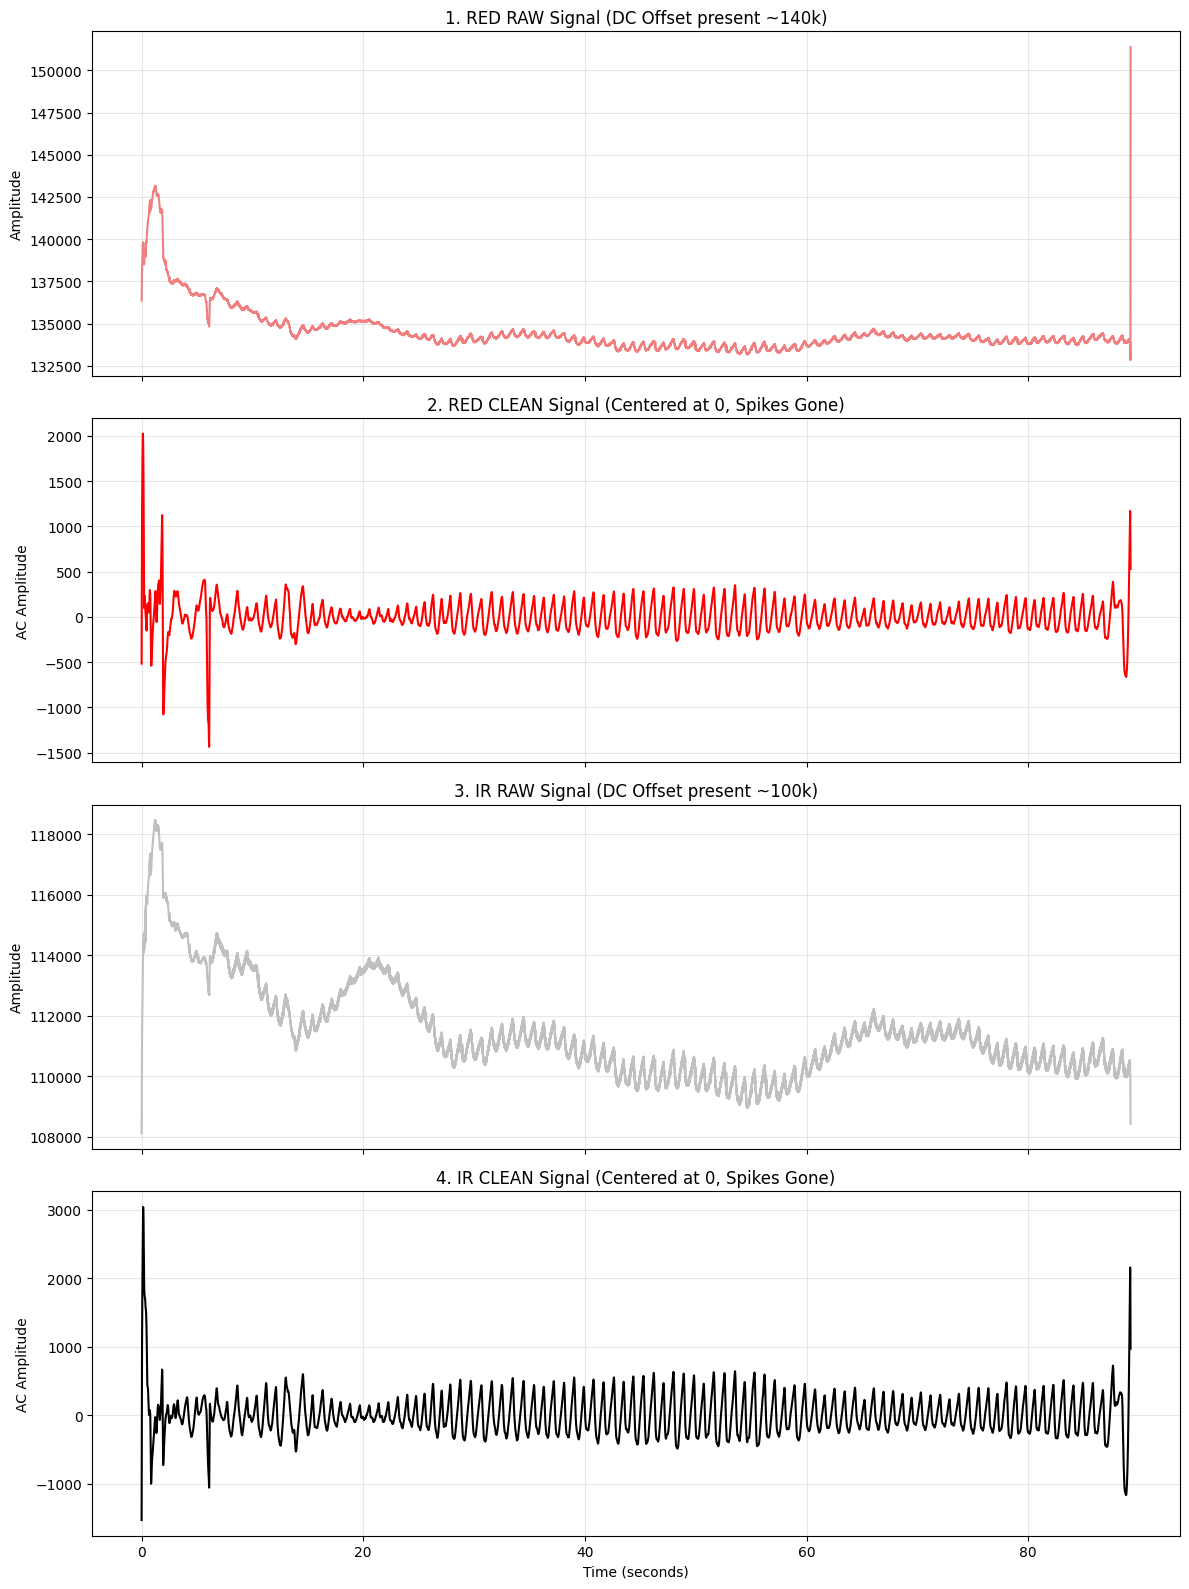

In [9]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration (MANUAL SETTINGS)
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   
FS = 400.0                      # Sampling Frequency (Hz)

# --- FILTER SETTINGS ---
LP_CUTOFF = 16.0                # Low-Pass (Removes Jitter)
LP_ORDER = 4
HP_CUTOFF = 0.5                 # High-Pass (Removes Drift/DC)
HP_ORDER = 4
KERNEL_SIZE = 7                 # Median Filter (Removes Spikes)

# --- THRESHOLDS ---
THRESHOLD_RED = 132000          
THRESHOLD_IR  = 108000          

# ==========================================
# 2. Filter Function (The Pipeline)
# ==========================================
def apply_full_ppg_pipeline(raw_data, fs, lp_cutoff, lp_order, hp_cutoff, hp_order, kernel_size):
    """
    Pipeline: Despike -> HighPass (Remove DC) -> LowPass (Smooth)
    """
    if len(raw_data) < 30: return np.zeros_like(raw_data) 
    if kernel_size % 2 == 0: kernel_size += 1

    # 1. Despike
    despiked = signal.medfilt(raw_data, kernel_size=kernel_size)

    # 2. High-Pass (Removes the huge DC offset, centers signal at 0)
    nyquist = 0.5 * fs
    sos_hp = signal.butter(hp_order, hp_cutoff / nyquist, btype='high', analog=False, output='sos')
    hp_filtered = signal.sosfiltfilt(sos_hp, despiked)

    # 3. Low-Pass (Smoothes the AC signal)
    sos_lp = signal.butter(lp_order, lp_cutoff / nyquist, btype='low', analog=False, output='sos')
    final_signal = signal.sosfiltfilt(sos_lp, hp_filtered)
    
    return final_signal

# ==========================================
# 3. Main Pipeline
# ==========================================
try:
    df = pd.read_csv(FILENAME)
    
    # Standardize Names
    df.columns = df.columns.str.strip().str.upper()
    rename_map = {'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'}
    df = df.rename(columns=rename_map)
    
    # Apply Thresholds
    mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
    clean_df = df[mask].copy()

    if len(clean_df) < 50:
        print(f"❌ Error: Data too short. Lower your thresholds.")
    else:
        print(f"✅ Processing {len(clean_df)} samples...")

        # --- Process Data ---
        red_clean = apply_full_ppg_pipeline(
            clean_df['RED'].values, FS, LP_CUTOFF, LP_ORDER, HP_CUTOFF, HP_ORDER, KERNEL_SIZE
        )
        ir_clean = apply_full_ppg_pipeline(
            clean_df['IR'].values, FS, LP_CUTOFF, LP_ORDER, HP_CUTOFF, HP_ORDER, KERNEL_SIZE
        )
        
        # --- 📊 PLOTTING (4 PLOTS STACKED VERTICALLY) ---
        t = np.arange(len(red_clean)) / FS
        
        # 'sharex=True' means if you zoom in one plot, ALL of them zoom together!
        fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

        # 1. RED RAW
        axes[0].plot(t, clean_df['RED'].values, color='lightcoral')
        axes[0].set_title(f'1. RED RAW Signal (DC Offset present ~140k)')
        axes[0].set_ylabel('Amplitude')
        axes[0].grid(True, alpha=0.3)

        # 2. RED CLEAN
        axes[1].plot(t, red_clean, color='red', linewidth=1.5)
        axes[1].set_title(f'2. RED CLEAN Signal (Centered at 0, Spikes Gone)')
        axes[1].set_ylabel('AC Amplitude')
        axes[1].grid(True, alpha=0.3)

        # 3. IR RAW
        axes[2].plot(t, clean_df['IR'].values, color='silver')
        axes[2].set_title(f'3. IR RAW Signal (DC Offset present ~100k)')
        axes[2].set_ylabel('Amplitude')
        axes[2].grid(True, alpha=0.3)

        # 4. IR CLEAN
        axes[3].plot(t, ir_clean, color='black', linewidth=1.5)
        axes[3].set_title(f'4. IR CLEAN Signal (Centered at 0, Spikes Gone)')
        axes[3].set_ylabel('AC Amplitude')
        axes[3].set_xlabel('Time (seconds)')
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

In [11]:
import scipy.stats as stats
import numpy as np

# ==========================================
# 5. Signal Quality Check Function (CORRECTED)
# ==========================================
def analyze_signal_quality(clean_data, raw_data, signal_name="Signal"):
    """
    Calculates Skewness, Kurtosis, and Perfusion Index (PI).
    Requires BOTH Clean (AC) and Raw (DC) data for accurate PI.
    """
    # 1. Statistical Features (Calculate on CLEAN signal to check shape)
    skew = stats.skew(clean_data)
    kurt = stats.kurtosis(clean_data)
    
    # 2. Perfusion Index (PI) Calculation
    # AC = Peak-to-Peak Amplitude of the CLEAN (Filtered) Signal
    ac_component = np.max(clean_data) - np.min(clean_data)
    
    # DC = Average Value of the RAW (Unfiltered) Signal
    dc_component = np.mean(raw_data)
    
    # Safety Check for Divide by Zero
    if dc_component == 0: 
        pi = 0
    else:
        pi = (ac_component / dc_component) * 100
    
    # 3. Quality Decision Logic (Heuristics)
    quality_status = "✅ GOOD"
    
    # Check 1: Is the signal skewed? (Healthy PPG has sharp peaks => Positive Skew)
    if skew < 0.2:             
        quality_status = "⚠️ WARNING: Signal looks sine-wave/noisy (Low Skew)"
    
    # Check 2: Is the PI high enough? (Below 0.1% is usually noise)
    if pi < 0.1:               
        quality_status = "❌ BAD: Signal too weak (Low Perfusion)"
    
    # Print Report
    print(f"--- {signal_name} QUALITY REPORT ---")
    print(f"   Skewness:        {skew:.4f}  (Target: > 0.2)")
    print(f"   Kurtosis:        {kurt:.4f}  (Target: > 0.0)")
    print(f"   Perfusion Index: {pi:.4f}%   (Target: > 0.1%)")
    print(f"   RESULT:          {quality_status}")
    print("-" * 40)
    
    return skew, kurt, pi

# ==========================================
# INSERT THIS INTO YOUR MAIN PIPELINE
# (Paste this right before plt.show())
# ==========================================

print("\n🔍 Running Quality Analysis...")

# 1. Analyze RED
# We pass 'red_clean' for AC and 'clean_df['RED']' for DC
analyze_signal_quality(red_clean, clean_df['RED'].values, "RED CHANNEL")

# 2. Analyze IR
# We pass 'ir_clean' for AC and 'clean_df['IR']' for DC
analyze_signal_quality(ir_clean, clean_df['IR'].values, "IR CHANNEL")


🔍 Running Quality Analysis...
--- RED CHANNEL QUALITY REPORT ---
   Skewness:        1.0276  (Target: > 0.2)
   Kurtosis:        21.5755  (Target: > 0.0)
   Perfusion Index: 2.5736%   (Target: > 0.1%)
   RESULT:          ✅ GOOD
----------------------------------------
--- IR CHANNEL QUALITY REPORT ---
   Skewness:        1.8293  (Target: > 0.2)
   Kurtosis:        14.4104  (Target: > 0.0)
   Perfusion Index: 4.1006%   (Target: > 0.1%)
   RESULT:          ✅ GOOD
----------------------------------------


(np.float64(1.8292565471012152),
 np.float64(14.410445757357419),
 np.float64(4.100568391373854))